## **Hypertension Analysis**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [ ]:
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_COMPLETE_CASE.csv")
df.head()

,hypertension,sbp_final,dbp_final,age,age_group,sex,education_level,marital_status,residence_type,division,...,household_size,sleeping_rooms,crowding_index,electricity,improved_water,improved_toilet,mobile_phone,sample_weight,cluster_id,strata_id
0,1,119.0,79.0,75.0,70+,2.0,2.0,3.0,1.0,1.0,...,4.0,3.0,1.333333,1.0,1,1,1.0,0.155639,1.0,1.0
1,1,139.0,95.0,55.0,50-59,1.0,3.0,1.0,1.0,1.0,...,4.0,3.0,1.333333,1.0,1,1,1.0,0.155639,1.0,1.0
2,1,129.0,97.0,46.0,40-49,2.0,3.0,1.0,1.0,1.0,...,4.0,3.0,1.333333,1.0,1,1,1.0,0.155639,1.0,1.0
3,1,138.5,90.0,51.0,50-59,1.0,0.0,1.0,1.0,1.0,...,3.0,2.0,1.500000,1.0,1,1,1.0,0.155639,1.0,1.0
4,0,108.5,84.0,35.0,30-39,2.0,0.0,1.0,1.0,1.0,...,3.0,2.0,1.500000,1.0,1,1,1.0,0.155639,1.0,1.0


In [ ]:
df.shape

(13399, 26)

In [ ]:
# ============================================================
# HOUSEHOLD SIZE CATEGORY
# ============================================================

df['household_size_cat'] = pd.cut(
    df['household_size'],
    bins=[0, 3, 6, np.inf],
    labels=[
        'Small',#(1-3)
        'Medium',# (4-6)
        'Large'# (7+)
    ]
)

# check
print(df['household_size_cat'].value_counts())

household_size_cat
Medium    7666
Small     3082
Large     2651
Name: count, dtype: int64


In [ ]:
# ============================================================
# CROWDING INDEX CATEGORY
# ============================================================

df['crowding_category'] = pd.cut(
    df['crowding_index'],
    bins=[0, 2, 3, np.inf],
    labels=[
        'Low',# (<2)
        'Moderate',# (2-3)
        'High'# (>3)
    ],
    include_lowest=True
)

# check
print(df['crowding_category'].value_counts())

crowding_category
Low         7871
Moderate    3482
High        2046
Name: count, dtype: int64


In [ ]:
df.columns

Index(['hypertension', 'sbp_final', 'dbp_final', 'age', 'age_group', 'sex',
       'education_level', 'marital_status', 'residence_type', 'division',
       'wealth_index', 'BMI', 'BMI_category', 'glucose', 'diabetes',
       'prediabetes', 'household_size', 'sleeping_rooms', 'crowding_index',
       'electricity', 'improved_water', 'improved_toilet', 'mobile_phone',
       'sample_weight', 'cluster_id', 'strata_id', 'household_size_cat',
       'crowding_category'],
      dtype='object')

In [ ]:
# ============================================================
# SELECT FINAL VARIABLES
# ============================================================

selected_vars = [
    'hypertension',          # outcome variable

    'age_group',
    'sex',
    'education_level',
    'marital_status',
    'residence_type',
    'division',
    'wealth_index',
    'BMI_category',
    'diabetes',
    'household_size_cat',
    'crowding_category',
    'electricity',
    'improved_water',
    'improved_toilet',
    'mobile_phone',
    'sample_weight',
    'cluster_id',
    'strata_id'
]

# create new dataset
df_final = df[selected_vars].copy()

# check
print(df_final.head())

# shape
print(df_final.shape)

   hypertension age_group  sex  education_level  marital_status  \
0             1       70+  2.0              2.0             3.0   
1             1     50-59  1.0              3.0             1.0   
2             1     40-49  2.0              3.0             1.0   
3             1     50-59  1.0              0.0             1.0   
4             0     30-39  2.0              0.0             1.0   

   residence_type  division  wealth_index BMI_category  diabetes  \
0             1.0       1.0           5.0        Obese         0   
1             1.0       1.0           5.0   Overweight         0   
2             1.0       1.0           5.0        Obese         1   
3             1.0       1.0           4.0       Normal         0   
4             1.0       1.0           4.0       Normal         0   

  household_size_cat crowding_category  electricity  improved_water  \
0             Medium               Low          1.0               1   
1             Medium               Low        

In [ ]:
# save as CSV
df_final.to_csv(
    "/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


## **Analysis BDHS hypertension dataset**

In [ ]:
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")
df.columns

Index(['hypertension', 'age_group', 'sex', 'education_level', 'marital_status',
       'residence_type', 'division', 'wealth_index', 'BMI_category',
       'diabetes', 'household_size_cat', 'crowding_category', 'electricity',
       'improved_water', 'improved_toilet', 'mobile_phone', 'sample_weight',
       'cluster_id', 'strata_id'],
      dtype='object')

In [ ]:
# ============================================================
# VALUE COUNTS FOR ALL PREDICTORS
# ============================================================

predictors = [
    'age_group',
    'sex',
    'education_level',
    'marital_status',
    'residence_type',
    'division',
    'wealth_index',
    'BMI_category',
    'diabetes',
    'household_size_cat',
    'crowding_category',
    'electricity',
    'improved_water',
    'improved_toilet',
    'mobile_phone'
]

# ============================================================
# LOOP THROUGH VARIABLES
# ============================================================

for var in predictors:

    print("\n" + "=" * 70)
    print(f"VARIABLE: {var}")
    print("=" * 70)

    # frequency
    freq = df[var].value_counts(dropna=False).sort_index()

    # percentage
    percent = round(df[var].value_counts(normalize=True, dropna=False)
                    .sort_index() * 100, 2)

    # combine
    summary = pd.DataFrame({
        "Count": freq,
        "Percent": percent
    })

    print(summary)


VARIABLE: age_group
           Count  Percent
age_group                
18-29       4023    30.02
30-39       3047    22.74
40-49       2401    17.92
50-59       1774    13.24
60-69       1385    10.34
70+          769     5.74

VARIABLE: sex
     Count  Percent
sex                
1.0   6004    44.81
2.0   7395    55.19

VARIABLE: education_level
                 Count  Percent
education_level                
0.0               3374    25.18
1.0               3394    25.33
2.0               4467    33.34
3.0               2164    16.15

VARIABLE: marital_status
                Count  Percent
marital_status                
0.0              1519    11.34
1.0             10643    79.43
3.0              1025     7.65
4.0               212     1.58

VARIABLE: residence_type
                Count  Percent
residence_type                
1.0              4605    34.37
2.0              8794    65.63

VARIABLE: division
          Count  Percent
division                
1.0        1435    10.71


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13399 entries, 0 to 13398
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hypertension        13399 non-null  int64  
 1   age_group           13399 non-null  object 
 2   sex                 13399 non-null  float64
 3   education_level     13399 non-null  float64
 4   marital_status      13399 non-null  float64
 5   residence_type      13399 non-null  float64
 6   division            13399 non-null  float64
 7   wealth_index        13399 non-null  float64
 8   BMI_category        13399 non-null  object 
 9   diabetes            13399 non-null  int64  
 10  household_size_cat  13399 non-null  object 
 11  crowding_category   13399 non-null  object 
 12  electricity         13399 non-null  float64
 13  improved_water      13399 non-null  int64  
 14  improved_toilet     13399 non-null  int64  
 15  mobile_phone        13399 non-null  float64
 16  samp

In [ ]:
df.columns

Index(['hypertension', 'age_group', 'sex', 'education_level', 'marital_status',
       'residence_type', 'division', 'wealth_index', 'BMI_category',
       'diabetes', 'household_size_cat', 'crowding_category', 'electricity',
       'improved_water', 'improved_toilet', 'mobile_phone', 'sample_weight',
       'cluster_id', 'strata_id'],
      dtype='object')

In [ ]:
df['hypertension'].value_counts()

,count
hypertension,
0,10647
1,2752


In [ ]:
# ==============================================================
# BDHS SURVEY-AWARE ML PIPELINE: THE GOLD STANDARD COMPARISON
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    confusion_matrix, roc_auc_score, accuracy_score,
    cohen_kappa_score, precision_score, recall_score, f1_score,
    roc_curve, brier_score_loss, auc, precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")

# ==============================================================
# 1. LOAD DATA & SPLIT
# ==============================================================
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")


target, design_cols = "hypertension", ["cluster_id", "strata_id", "sample_weight"]
df[target] = df[target].astype(int)


# ==============================================================
# FIX DATA TYPES FOR CATEGORICAL VARIABLES
# ==============================================================

categorical_vars = [
    'age_group',
    'sex',
    'education_level',
    'marital_status',
    'residence_type',
    'division',
    'wealth_index',
    'BMI_category',
    'diabetes',
    'household_size_cat',
    'crowding_category',
    'electricity',
    'improved_water',
    'improved_toilet',
    'mobile_phone'
]

for col in categorical_vars:
    df[col] = df[col].astype(str)



X = pd.get_dummies(df.drop(columns=[target] + design_cols), drop_first=True)
y, w, clusters = df[target], df["sample_weight"], df["cluster_id"]

# Split: 80% Train+Val / 20% Test (Cluster-Aware)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups=clusters))

# Split: 75% Train / 25% Val (Cluster-Aware)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(
    gss2.split(X.iloc[train_val_idx], y.iloc[train_val_idx],
               groups=clusters.iloc[train_val_idx])
)

X_train, y_train, w_train = X.iloc[train_idx], y.iloc[train_idx], w.iloc[train_idx]
X_val, y_val, w_val = X.iloc[val_idx], y.iloc[val_idx], w.iloc[val_idx]
X_test, y_test, w_test = X.iloc[test_idx], y.iloc[test_idx], w.iloc[test_idx]

## **Boostrap with all results**

Training: XGBoost...
Training: Random Forest...
Training: Gradient Boosting...
Training: Extra Trees...
Training: Logistic Regression...
Training: SVC...
Training: Decision Tree...

FINAL REPORT WITH 95% CIs
                  Model/Set                 Acc                 AUC              PR_AUC               Kappa           Precision              Recall                  F1               Brier               Slope                Sens                Spec Thresh
            XGBoost (Train) 0.723 (0.712-0.735) 0.873 (0.864-0.882) 0.649 (0.623-0.675) 0.399 (0.379-0.419) 0.415 (0.398-0.433) 0.885 (0.870-0.901) 0.565 (0.549-0.582) 0.107 (0.103-0.112) 1.001 (0.959-1.045) 0.885 (0.870-0.901) 0.682 (0.669-0.695)  0.139
              XGBoost (Val) 0.680 (0.660-0.700) 0.761 (0.734-0.785) 0.432 (0.384-0.478) 0.299 (0.261-0.337) 0.362 (0.331-0.395) 0.763 (0.722-0.805) 0.491 (0.457-0.524) 0.146 (0.136-0.157) 0.685 (0.626-0.743) 0.763 (0.722-0.805) 0.659 (0.637-0.682)  0.139
             XGBoost (Test)

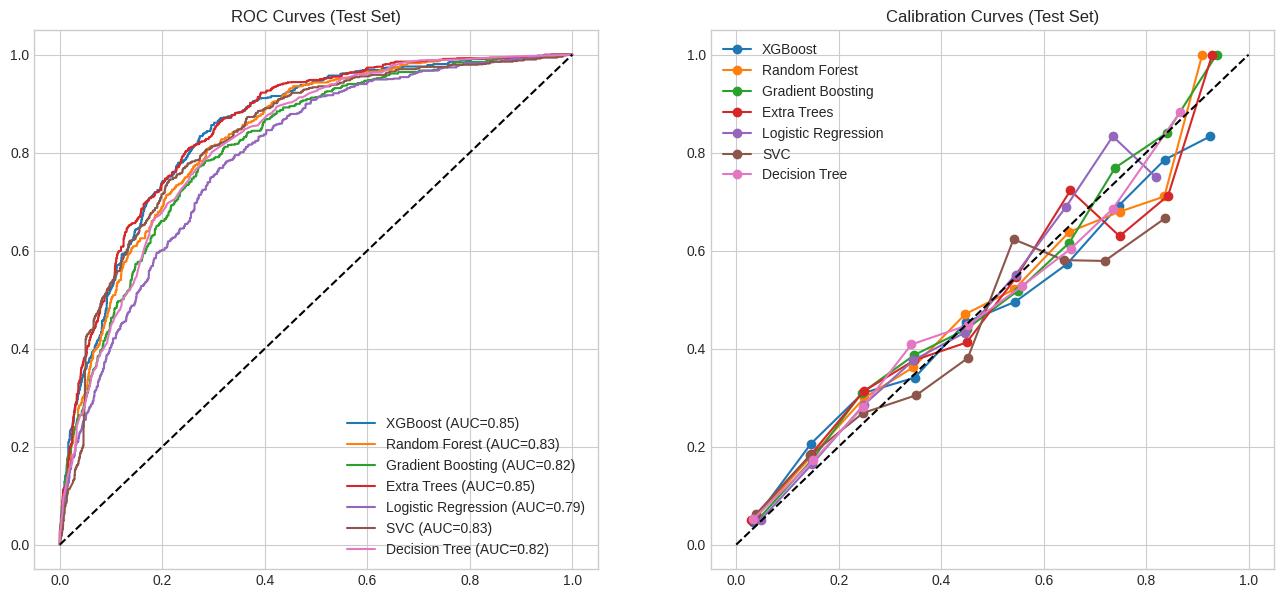

In [ ]:
# ==============================================================
# 2. CORE UTILITIES
# ==============================================================

def pr_auc_score(y_true, p, w):
    # Using average_precision_score as it is the standard weighted PR-AUC metric
    return average_precision_score(y_true, p, sample_weight=w)

def calibration_slope(y_true, p, w):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    # Fit weighted logistic regression to find slope
    lr = LogisticRegression(fit_intercept=False).fit(logit, y_true, sample_weight=w)
    return lr.coef_[0][0]

def get_calibrated_probs(model, X_set, y_train_set, train_raw_probs, w_train_set):
    eps = 1e-6
    train_raw_probs = np.clip(train_raw_probs, eps, 1-eps)
    logit_train = np.log(train_raw_probs / (1 - train_raw_probs)).reshape(-1, 1)

    calibrator = LogisticRegression(max_iter=1000)
    # Calibrator now respects training weights
    calibrator.fit(logit_train, y_train_set, sample_weight=w_train_set)

    raw_p = model.predict_proba(X_set)[:, 1]
    raw_p = np.clip(raw_p, eps, 1-eps)

    logit_set = np.log(raw_p / (1 - raw_p)).reshape(-1, 1)
    return calibrator.predict_proba(logit_set)[:, 1]

def evaluate_metrics(y_true, p, w, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, sample_weight=w).ravel()

    return {
        "Acc": accuracy_score(y_true, pred, sample_weight=w),
        "AUC": roc_auc_score(y_true, p, sample_weight=w),
        "PR_AUC": pr_auc_score(y_true, p, w),
        "Kappa": cohen_kappa_score(y_true, pred, sample_weight=w),
        "Precision": precision_score(y_true, pred, sample_weight=w),
        "Recall": recall_score(y_true, pred, sample_weight=w),
        "F1": f1_score(y_true, pred, sample_weight=w),
        "Brier": brier_score_loss(y_true, p, sample_weight=w),
        "Slope": calibration_slope(y_true, p, w),
        "Sens": tp / (tp + fn + 1e-9),
        "Spec": tn / (tn + fp + 1e-9),
        "Thresh": t
    }

def get_bootstrap_results(y, p, w, t, B=1000):
    rng = np.random.RandomState(42)
    n, boot_data = len(y), []
    p_arr = np.array(p) # Convert to array for robust indexing

    for _ in range(B):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        y_b, p_b, w_b = y.iloc[idx], p_arr[idx], w.iloc[idx]

        if len(np.unique(y_b)) < 2:
            continue

        m = evaluate_metrics(y_b, p_b, w_b, t)
        boot_data.append(list(m.values()))

    boot_data = np.array(boot_data)
    means = np.mean(boot_data, axis=0)
    lower = np.percentile(boot_data, 2.5, axis=0)
    upper = np.percentile(boot_data, 97.5, axis=0)

    return [
        f"{m:.3f} ({l:.3f}-{u:.3f})" if i != (len(means)-1) else f"{m:.3f}"
        for i, (m, l, u) in enumerate(zip(means, lower, upper))
    ]

# ==============================================================
# 3. MODELS & LOOP
# ==============================================================

ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "XGBoost": XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=ratio,
    eval_metric="auc",
    tree_method="hist",
    random_state=42
),
    "Random Forest": RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
),
    "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
),
    "Extra Trees": ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
),
    "Logistic Regression": LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
),
    "SVC": SVC(
    C=1,
    gamma="scale",
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
),
    "Decision Tree": DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=20,
    min_samples_split=40,
    class_weight="balanced",
    random_state=42
)
}
master_results, plot_data = [], {}

for name, model in models.items():
    print(f"Training: {name}...")

    if name == "XGBoost":
        model.fit(X_train, y_train, sample_weight=w_train,
                  eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val], verbose=False)
    else:
        model.fit(X_train, y_train, sample_weight=w_train)

    train_raw = model.predict_proba(X_train)[:, 1]

    # Pass w_train to calibration
    train_prob = get_calibrated_probs(model, X_train, y_train, train_raw, w_train)
    val_prob   = get_calibrated_probs(model, X_val, y_train, train_raw, w_train)
    test_prob  = get_calibrated_probs(model, X_test, y_train, train_raw, w_train)

    # Threshold tuning (Youden’s J)
    thresholds = np.linspace(0.01, 0.99, 100)
    best_t, best_j = 0, -1

    for t in thresholds:
        preds = (val_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, preds, sample_weight=w_val).ravel()
        j = (tp/(tp+fn+1e-9)) + (tn/(tn+fp+1e-9)) - 1
        if j > best_j:
            best_j, best_t = j, t

    master_results.append([f"{name} (Train)"] + get_bootstrap_results(y_train, train_prob, w_train, best_t))
    master_results.append([f"{name} (Val)"]   + get_bootstrap_results(y_val, val_prob, w_val, best_t))
    master_results.append([f"{name} (Test)"]  + get_bootstrap_results(y_test, test_prob, w_test, best_t))

    plot_data[name] = test_prob

# ==============================================================
# 4. OUTPUTS
# ==============================================================

cols = ["Model/Set", "Acc", "AUC", "PR_AUC", "Kappa", "Precision", "Recall", "F1", "Brier", "Slope", "Sens", "Spec", "Thresh"]
print("\n" + "="*160 + "\nFINAL REPORT WITH 95% CIs\n" + "="*160)
print(pd.DataFrame(master_results, columns=cols).to_string(index=False))

# --- ROC & Calibration Plots ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for name, probs in plot_data.items():
    fpr, tpr, _ = roc_curve(y_test, probs, sample_weight=w_test)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    p_true, p_pred = calibration_curve(y_test, probs, n_bins=10)
    ax2.plot(p_pred, p_true, 'o-', label=name)

ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title("ROC Curves (Test Set)")
ax1.legend()

ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_title("Calibration Curves (Test Set)")
ax2.legend()
plt.show()

In [ ]:
# ==============================================================
# 6. ✅ ADDED TABLES (NEW — NO CHANGES ABOVE)
# ==============================================================

def calibration_intercept(y_true, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    logit = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression().fit(logit, y_true)
    return lr.intercept_[0]

def weighted_cm(y_true, p, w, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, sample_weight=w).ravel()
    return tp, fp, fn, tn

# ---------------- CONFUSION MATRIX ----------------

cm_table = []

for name, probs in plot_data.items():
    t = 0.5

    tp, fp, fn, tn = weighted_cm(y_test, probs, w_test, t)

    cm_table.append([name, tp, fp, fn, tn])

cm_df = pd.DataFrame(cm_table, columns=["Model","TP","FP","FN","TN"])
print("\nCONFUSION MATRIX")
print(cm_df)

# ---------------- METRICS TABLE ----------------

metrics_table = []

for name, probs in plot_data.items():
    t = 0.5
    tp, fp, fn, tn = weighted_cm(y_test, probs, w_test, t)

    sens = tp/(tp+fn+1e-9)
    spec = tn/(tn+fp+1e-9)
    ppv = tp/(tp+fp+1e-9)
    npv = tn/(tn+fn+1e-9)

    metrics_table.append([name, sens, spec, ppv, npv])

metrics_df = pd.DataFrame(metrics_table,
                          columns=["Model","Sens","Spec","PPV","NPV"])

print("\nMETRICS")
print(metrics_df)

# ---------------- CALIBRATION TABLE ----------------

cal_table = []

for name, probs in plot_data.items():
    slope = calibration_slope(y_test.values, probs)
    intercept = calibration_intercept(y_test.values, probs)
    brier = brier_score_loss(y_test, probs, sample_weight=w_test)

    cal_table.append([name, slope, intercept, brier])

cal_df = pd.DataFrame(cal_table,
                      columns=["Model","Slope","Intercept","Brier"])

print("\nCALIBRATION")
print(cal_df)


CONFUSION MATRIX
                 Model          TP          FP          FN           TN
0              XGBoost  236.475218  144.395609  349.291689  1963.225321
1        Random Forest  211.150397  123.905842  374.616510  1983.715088
2    Gradient Boosting  200.967647  126.964537  384.799260  1980.656393
3          Extra Trees  251.390253  130.451035  334.376654  1977.169895
4  Logistic Regression  133.527262   79.955549  452.239645  2027.665381
5                  SVC  281.793566  162.249118  303.973341  1945.371812
6        Decision Tree  178.951375  110.289195  406.815532  1997.331735

METRICS
                 Model      Sens      Spec       PPV       NPV
0              XGBoost  0.403702  0.931489  0.620880  0.848956
1        Random Forest  0.360468  0.941211  0.630194  0.841152
2    Gradient Boosting  0.343085  0.939759  0.612833  0.837326
3          Extra Trees  0.429164  0.938105  0.658363  0.855345
4  Logistic Regression  0.227953  0.962064  0.625471  0.817638
5                  

TypeError: calibration_slope() missing 1 required positional argument: 'w'

## **Without Boostrap Results**

Training: XGBoost...
Training: Random Forest...
Training: Gradient Boosting...
Training: Extra Trees...
Training: Logistic Regression...
Training: SVC...
Training: Decision Tree...

FINAL REPORT
                  Model/Set   Acc   AUC  PR_AUC  Kappa  Precision  Recall    F1  Brier  Slope  Sens  Spec  Thresh
            XGBoost (Train) 0.723 0.872   0.648  0.399      0.415   0.885 0.565  0.107  1.001 0.885 0.682   0.139
              XGBoost (Val) 0.680 0.761   0.429  0.298      0.361   0.763 0.491  0.146  0.686 0.763 0.659   0.139
             XGBoost (Test) 0.723 0.849   0.605  0.404      0.432   0.871 0.578  0.122  0.871 0.871 0.682   0.139
      Random Forest (Train) 0.707 0.857   0.601  0.370      0.398   0.865 0.545  0.115  1.001 0.865 0.667   0.149
        Random Forest (Val) 0.674 0.762   0.418  0.289      0.356   0.759 0.484  0.144  0.739 0.759 0.652   0.149
       Random Forest (Test) 0.705 0.834   0.567  0.369      0.413   0.838 0.553  0.127  0.878 0.838 0.668   0.149
  Gradi

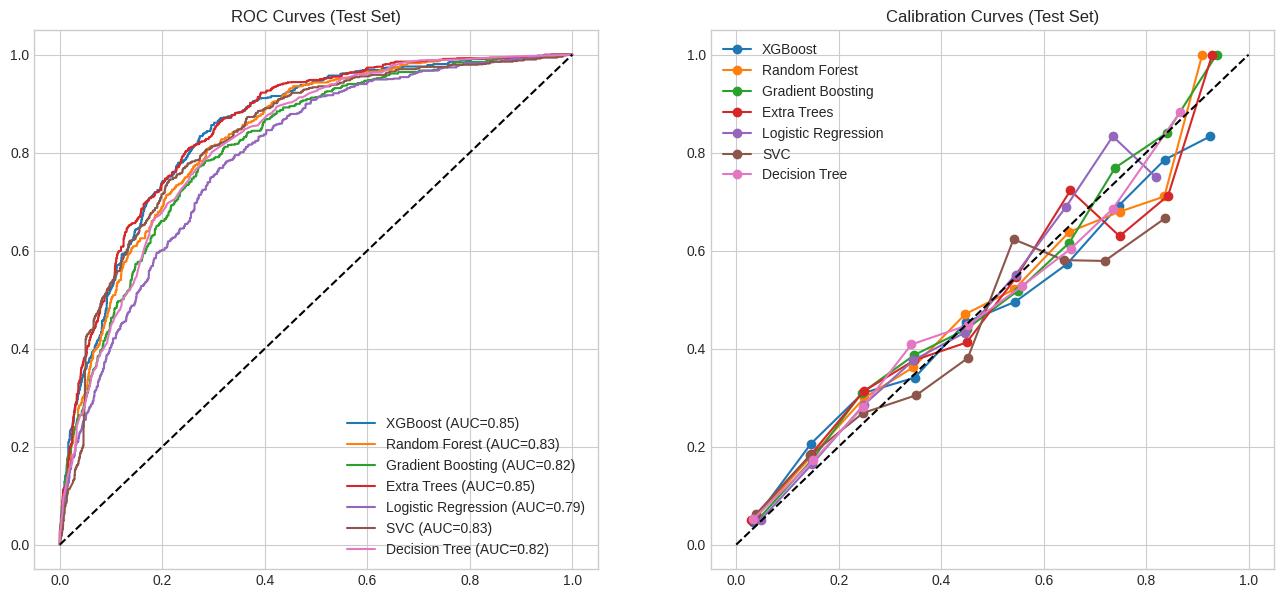

In [ ]:
# ==============================================================
# BDHS SURVEY-AWARE ML PIPELINE: THE GOLD STANDARD COMPARISON
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    confusion_matrix, roc_auc_score, accuracy_score,
    cohen_kappa_score, precision_score, recall_score, f1_score,
    roc_curve, brier_score_loss, auc, precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")

# ==============================================================
# 1. LOAD DATA & SPLIT
# ==============================================================
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")


target, design_cols = "hypertension", ["cluster_id", "strata_id", "sample_weight"]
df[target] = df[target].astype(int)


# ==============================================================
# FIX DATA TYPES FOR CATEGORICAL VARIABLES
# ==============================================================

categorical_vars = [
    'age_group',
    'sex',
    'education_level',
    'marital_status',
    'residence_type',
    'division',
    'wealth_index',
    'BMI_category',
    'diabetes',
    'household_size_cat',
    'crowding_category',
    'electricity',
    'improved_water',
    'improved_toilet',
    'mobile_phone'
]

for col in categorical_vars:
    df[col] = df[col].astype(str)



X = pd.get_dummies(df.drop(columns=[target] + design_cols), drop_first=True)
y, w, clusters = df[target], df["sample_weight"], df["cluster_id"]

# Split: 80% Train+Val / 20% Test (Cluster-Aware)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups=clusters))

# Split: 75% Train / 25% Val (Cluster-Aware)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(
    gss2.split(X.iloc[train_val_idx], y.iloc[train_val_idx],
               groups=clusters.iloc[train_val_idx])
)

X_train, y_train, w_train = X.iloc[train_idx], y.iloc[train_idx], w.iloc[train_idx]
X_val, y_val, w_val = X.iloc[val_idx], y.iloc[val_idx], w.iloc[val_idx]
X_test, y_test, w_test = X.iloc[test_idx], y.iloc[test_idx], w.iloc[test_idx]









# ==============================================================
# 2. CORE UTILITIES
# ==============================================================

def pr_auc_score(y_true, p, w):
    return average_precision_score(y_true, p, sample_weight=w)

def calibration_slope(y_true, p, w):
    p = np.clip(p, 1e-6, 1-1e-6)

    logit = np.log(p / (1 - p)).reshape(-1, 1)

    lr = LogisticRegression(fit_intercept=False)

    lr.fit(logit, y_true, sample_weight=w)

    return lr.coef_[0][0]

def get_calibrated_probs(model, X_set, y_train_set, train_raw_probs, w_train_set):

    eps = 1e-6

    train_raw_probs = np.clip(train_raw_probs, eps, 1-eps)

    logit_train = np.log(
        train_raw_probs / (1 - train_raw_probs)
    ).reshape(-1, 1)

    calibrator = LogisticRegression(max_iter=1000)

    calibrator.fit(logit_train,y_train_set,sample_weight=w_train_set)

    raw_p = model.predict_proba(X_set)[:, 1]

    raw_p = np.clip(raw_p, eps, 1-eps)

    logit_set = np.log(raw_p / (1 - raw_p)).reshape(-1, 1)

    return calibrator.predict_proba(logit_set)[:, 1]

def evaluate_metrics(y_true, p, w, t):

    pred = (p >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true,pred,sample_weight=w).ravel()

    return {
        "Acc": accuracy_score(y_true, pred,sample_weight=w),

        "AUC": roc_auc_score(y_true,p,sample_weight=w),

        "PR_AUC": pr_auc_score(y_true,p,w),

        "Kappa": cohen_kappa_score(y_true,pred,sample_weight=w),

        "Precision": precision_score(y_true,pred,sample_weight=w),

        "Recall": recall_score(y_true,pred,sample_weight=w),

        "F1": f1_score(y_true,pred,sample_weight=w),

        "Brier": brier_score_loss(y_true,p,sample_weight=w),

        "Slope": calibration_slope(y_true,p,w),

        "Sens": tp / (tp + fn + 1e-9),

        "Spec": tn / (tn + fp + 1e-9),

        "Thresh": t
    }

# ==============================================================
# 3. MODELS & LOOP
# ==============================================================

ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {

    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0.2,
        reg_alpha=0.1,
        reg_lambda=1,
        scale_pos_weight=ratio,
        eval_metric="auc",
        tree_method="hist",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),

    "SVC": SVC(
        C=1,
        gamma="scale",
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        class_weight="balanced",
        random_state=42
    )
}

master_results = []
plot_data = {}

for name, model in models.items():

    print(f"Training: {name}...")

    # ==========================================================
    # MODEL FITTING
    # ==========================================================

    if name == "XGBoost":

        model.fit(
            X_train,
            y_train,
            sample_weight=w_train,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[w_val],
            verbose=False
        )

    else:

        model.fit(
            X_train,
            y_train,
            sample_weight=w_train
        )

    # ==========================================================
    # CALIBRATED PROBABILITIES
    # ==========================================================

    train_raw = model.predict_proba(X_train)[:, 1]

    train_prob = get_calibrated_probs(
        model,
        X_train,
        y_train,
        train_raw,
        w_train
    )

    val_prob = get_calibrated_probs(
        model,
        X_val,
        y_train,
        train_raw,
        w_train
    )

    test_prob = get_calibrated_probs(
        model,
        X_test,
        y_train,
        train_raw,
        w_train
    )

    # ==========================================================
    # THRESHOLD TUNING
    # ==========================================================

    thresholds = np.linspace(0.01, 0.99, 100)

    best_t = 0
    best_j = -1

    for t in thresholds:

        preds = (val_prob >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val,
            preds,
            sample_weight=w_val
        ).ravel()

        j = (
            (tp / (tp + fn + 1e-9))
            +
            (tn / (tn + fp + 1e-9))
            - 1
        )

        if j > best_j:
            best_j = j
            best_t = t

    # ==========================================================
    # FINAL METRICS
    # ==========================================================

    train_metrics = evaluate_metrics(
        y_train,
        train_prob,
        w_train,
        best_t
    )

    val_metrics = evaluate_metrics(
        y_val,
        val_prob,
        w_val,
        best_t
    )

    test_metrics = evaluate_metrics(
        y_test,
        test_prob,
        w_test,
        best_t
    )

    master_results.append(
        [f"{name} (Train)"] + list(train_metrics.values())
    )

    master_results.append(
        [f"{name} (Val)"] + list(val_metrics.values())
    )

    master_results.append(
        [f"{name} (Test)"] + list(test_metrics.values())
    )

    plot_data[name] = test_prob

# ==============================================================
# 4. OUTPUTS
# ==============================================================

cols = [
    "Model/Set",
    "Acc",
    "AUC",
    "PR_AUC",
    "Kappa",
    "Precision",
    "Recall",
    "F1",
    "Brier",
    "Slope",
    "Sens",
    "Spec",
    "Thresh"
]

results_df = pd.DataFrame(
    master_results,
    columns=cols
)

print("\n" + "="*160)
print("FINAL REPORT")
print("="*160)

print(results_df.round(3).to_string(index=False))

# ==============================================================
# ROC & CALIBRATION PLOTS
# ==============================================================

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

for name, probs in plot_data.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probs,
        sample_weight=w_test
    )

    ax1.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc(fpr, tpr):.2f})'
    )

    p_true, p_pred = calibration_curve(
        y_test,
        probs,
        n_bins=10
    )

    ax2.plot(
        p_pred,
        p_true,
        'o-',
        label=name
    )

ax1.plot([0, 1], [0, 1], 'k--')

ax1.set_title("ROC Curves (Test Set)")
ax1.legend()

ax2.plot([0, 1], [0, 1], 'k--')

ax2.set_title("Calibration Curves (Test Set)")
ax2.legend()

plt.show()